In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [4]:
df = pd.read_csv('liver_cirrhosis.csv')

In [6]:
df.head()

,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,2221,C,Placebo,18499,F,N,Y,N,N,0.5,149.0,4.04,227.0,598.0,52.70,57.0,256.0,9.9,1
1,1230,C,Placebo,19724,M,Y,N,Y,N,0.5,219.0,3.93,22.0,663.0,45.00,75.0,220.0,10.8,2
2,4184,C,Placebo,11839,F,N,N,N,N,0.5,320.0,3.54,51.0,1243.0,122.45,80.0,225.0,10.0,2
3,2090,D,Placebo,16467,F,N,N,N,N,0.7,255.0,3.74,23.0,1024.0,77.50,58.0,151.0,10.2,2
4,2105,D,Placebo,21699,F,N,Y,N,N,1.9,486.0,3.54,74.0,1052.0,108.50,109.0,151.0,11.5,1


In [8]:
# 1. BASIC DATA OVERVIEW
print("\n1. DATASET OVERVIEW")
print("-" * 30)
print(f"Dataset shape: {df.shape}")
print(f"Number of patients: {len(df)}")
print(f"Number of features: {len(df.columns)}")

print("\nColumn names and types:")
print(df.dtypes)

print("\nFirst few rows:")
print(df.head())

print("\nDataset info:")
df.info()



1. DATASET OVERVIEW
------------------------------
Dataset shape: (25000, 19)
Number of patients: 25000
Number of features: 19

Column names and types:
N_Days             int64
Status            object
Drug              object
Age                int64
Sex               object
Ascites           object
Hepatomegaly      object
Spiders           object
Edema             object
Bilirubin        float64
Cholesterol      float64
Albumin          float64
Copper           float64
Alk_Phos         float64
SGOT             float64
Tryglicerides    float64
Platelets        float64
Prothrombin      float64
Stage              int64
dtype: object

First few rows:
   N_Days Status     Drug    Age Sex Ascites Hepatomegaly Spiders Edema  \
0    2221      C  Placebo  18499   F       N            Y       N     N   
1    1230      C  Placebo  19724   M       Y            N       Y     N   
2    4184      C  Placebo  11839   F       N            N       N     N   
3    2090      D  Placebo  16467   F     



2. TARGET VARIABLE ANALYSIS - STAGE
----------------------------------------
Stage distribution:
Stage
1    8265
2    8441
3    8294
Name: count, dtype: int64

Stage percentages:
Stage
1    33.06
2    33.76
3    33.18
Name: count, dtype: float64


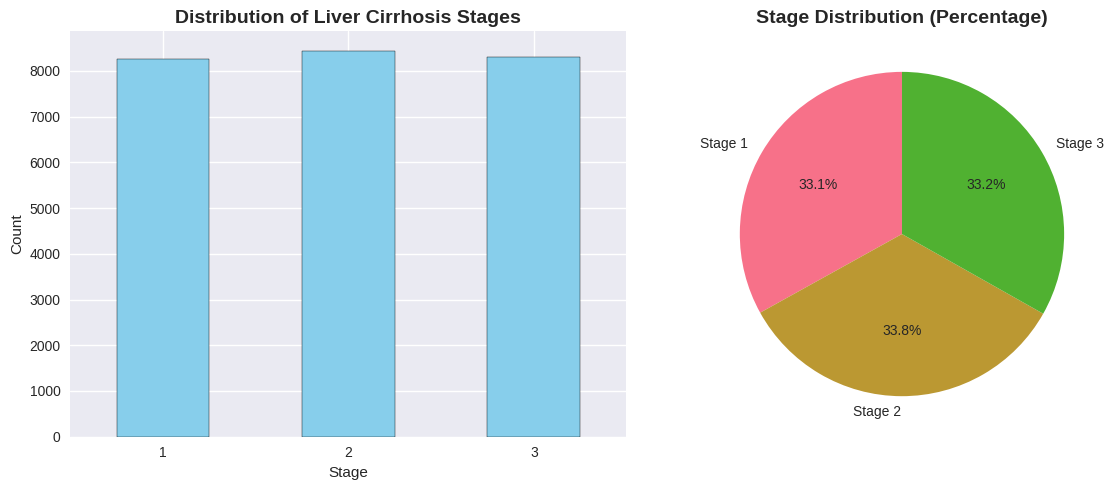

In [9]:
# 2. TARGET VARIABLE ANALYSIS
print("\n\n2. TARGET VARIABLE ANALYSIS - STAGE")
print("-" * 40)

# Stage distribution
stage_counts = df['Stage'].value_counts().sort_index()
print("Stage distribution:")
print(stage_counts)
print(f"\nStage percentages:")
print((stage_counts / len(df) * 100).round(2))

# Visualize target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
stage_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Liver Cirrhosis Stages', fontsize=14, fontweight='bold')
ax1.set_xlabel('Stage')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

# Pie chart
ax2.pie(stage_counts.values, labels=[f'Stage {i}' for i in stage_counts.index],
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Stage Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# 3. MISSING VALUES ANALYSIS
print("\n\n3. MISSING VALUES ANALYSIS")
print("-" * 30)

missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
}).sort_values('Missing Count', ascending=False)

print("Missing values summary:")
print(missing_df[missing_df['Missing Count'] > 0])

# Visualize missing data
if missing_df['Missing Count'].sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    plt.barh(range(len(missing_cols)), missing_cols['Missing Percentage'], color='coral')
    plt.yticks(range(len(missing_cols)), missing_cols.index)
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Data Analysis', fontsize=14, fontweight='bold')
    plt.show()
else:
    print("No missing values found in the dataset!")



3. MISSING VALUES ANALYSIS
------------------------------
Missing values summary:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []
No missing values found in the dataset!




4. NUMERICAL FEATURES ANALYSIS
-----------------------------------
Basic statistics for numerical features:
         N_Days       Age  Bilirubin  Cholesterol   Albumin    Copper  \
count  25000.00  25000.00   25000.00     25000.00  25000.00  25000.00   
mean    1887.12  18495.88       3.40       372.33      3.49    100.18   
std     1091.69   3737.60       4.71       193.67      0.38     73.18   
min       41.00   9598.00       0.30       120.00      1.96      4.00   
25%     1080.00  15694.00       0.80       275.00      3.29     52.00   
50%     1680.00  18499.00       1.30       369.51      3.51     97.65   
75%     2576.00  20955.00       3.40       369.51      3.75    107.00   
max     4795.00  28650.00      28.00      1775.00      4.64    588.00   

       Alk_Phos      SGOT  Tryglicerides  Platelets  Prothrombin  
count  25000.00  25000.00       25000.00   25000.00     25000.00  
mean    1995.68    123.17         123.82     256.01        10.73  
std     1798.89     47.75      

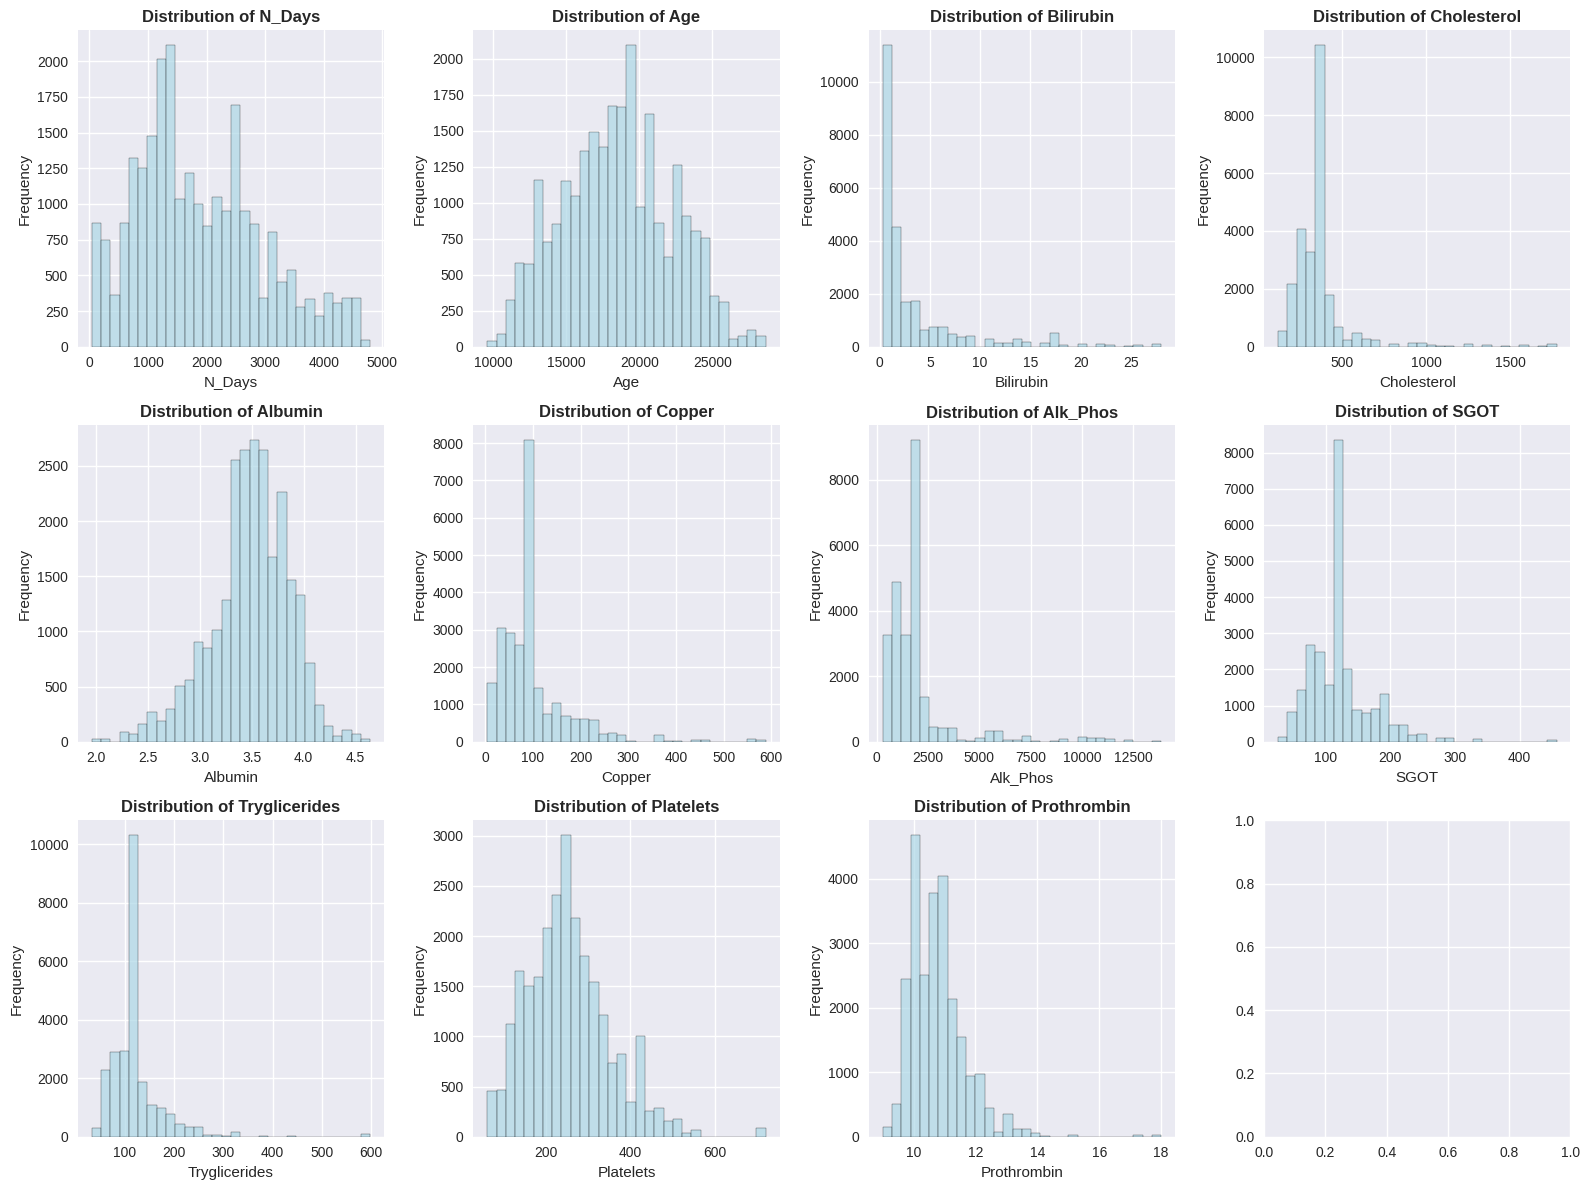

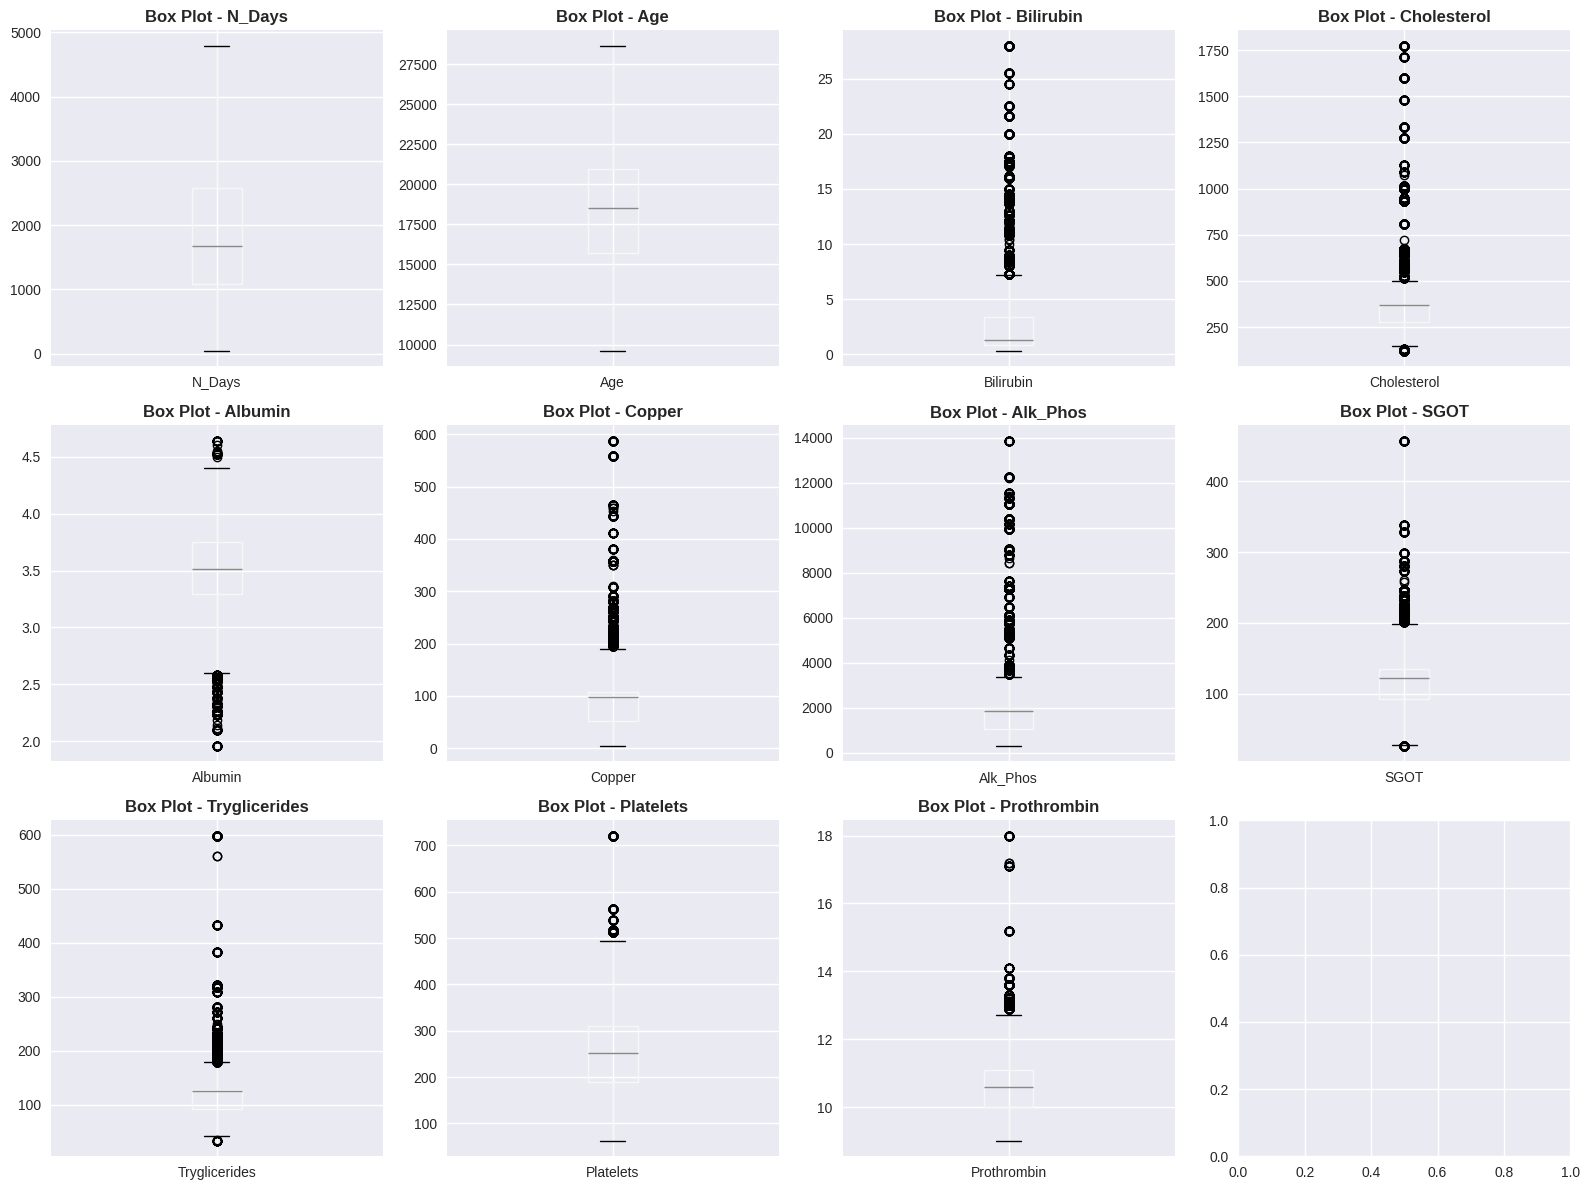

In [11]:
# 4. NUMERICAL FEATURES ANALYSIS
print("\n\n4. NUMERICAL FEATURES ANALYSIS")
print("-" * 35)

# Identify numerical columns
numerical_cols = ['N_Days', 'Age', 'Bilirubin', 'Cholesterol', 'Albumin',
                  'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin']

# Basic statistics
print("Basic statistics for numerical features:")
print(df[numerical_cols].describe().round(2))

# Distribution plots for key numerical features
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    df[col].hist(bins=30, ax=axes[i], alpha=0.7, color='lightblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plots to identify outliers
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Box Plot - {col}', fontweight='bold')

plt.tight_layout()
plt.show()




5. CATEGORICAL FEATURES ANALYSIS
-----------------------------------

Status distribution:
Status
C     13516
D      9456
CL     2028
Name: count, dtype: int64
Percentage distribution:
Status
C     54.06
D     37.82
CL     8.11
Name: proportion, dtype: float64

Drug distribution:
Drug
Placebo            15827
D-penicillamine     9173
Name: count, dtype: int64
Percentage distribution:
Drug
Placebo            63.31
D-penicillamine    36.69
Name: proportion, dtype: float64

Sex distribution:
Sex
F    22137
M     2863
Name: count, dtype: int64
Percentage distribution:
Sex
F    88.55
M    11.45
Name: proportion, dtype: float64

Ascites distribution:
Ascites
N    16798
Y     8202
Name: count, dtype: int64
Percentage distribution:
Ascites
N    67.19
Y    32.81
Name: proportion, dtype: float64

Hepatomegaly distribution:
Hepatomegaly
N    15243
Y     9757
Name: count, dtype: int64
Percentage distribution:
Hepatomegaly
N    60.97
Y    39.03
Name: proportion, dtype: float64

Spiders distributi

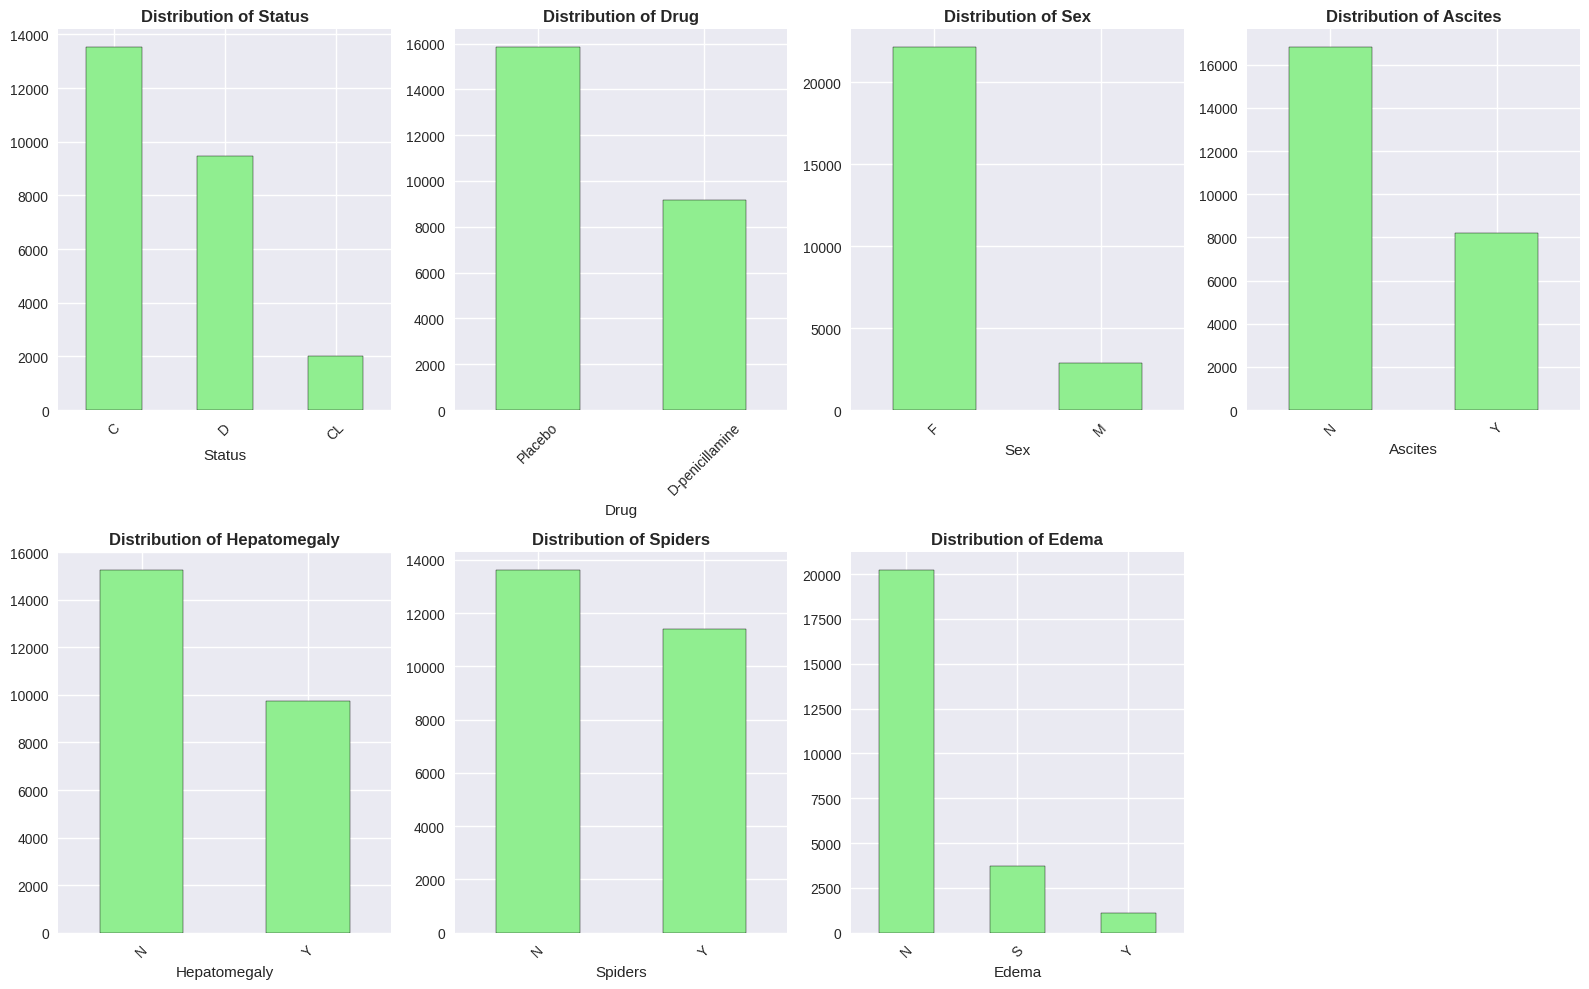

In [12]:
# 5. CATEGORICAL FEATURES ANALYSIS
print("\n\n5. CATEGORICAL FEATURES ANALYSIS")
print("-" * 35)

categorical_cols = ['Status', 'Drug', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders', 'Edema']

for col in categorical_cols:
    print(f"\n{col} distribution:")
    print(df[col].value_counts())
    print(f"Percentage distribution:")
    print((df[col].value_counts(normalize=True) * 100).round(2))

# Visualize categorical features
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        df[col].value_counts().plot(kind='bar', ax=axes[i], color='lightgreen', edgecolor='black')
        axes[i].set_title(f'Distribution of {col}', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplot
if len(categorical_cols) < len(axes):
    fig.delaxes(axes[len(categorical_cols)])

plt.tight_layout()
plt.show()




6. CORRELATION ANALYSIS
-------------------------


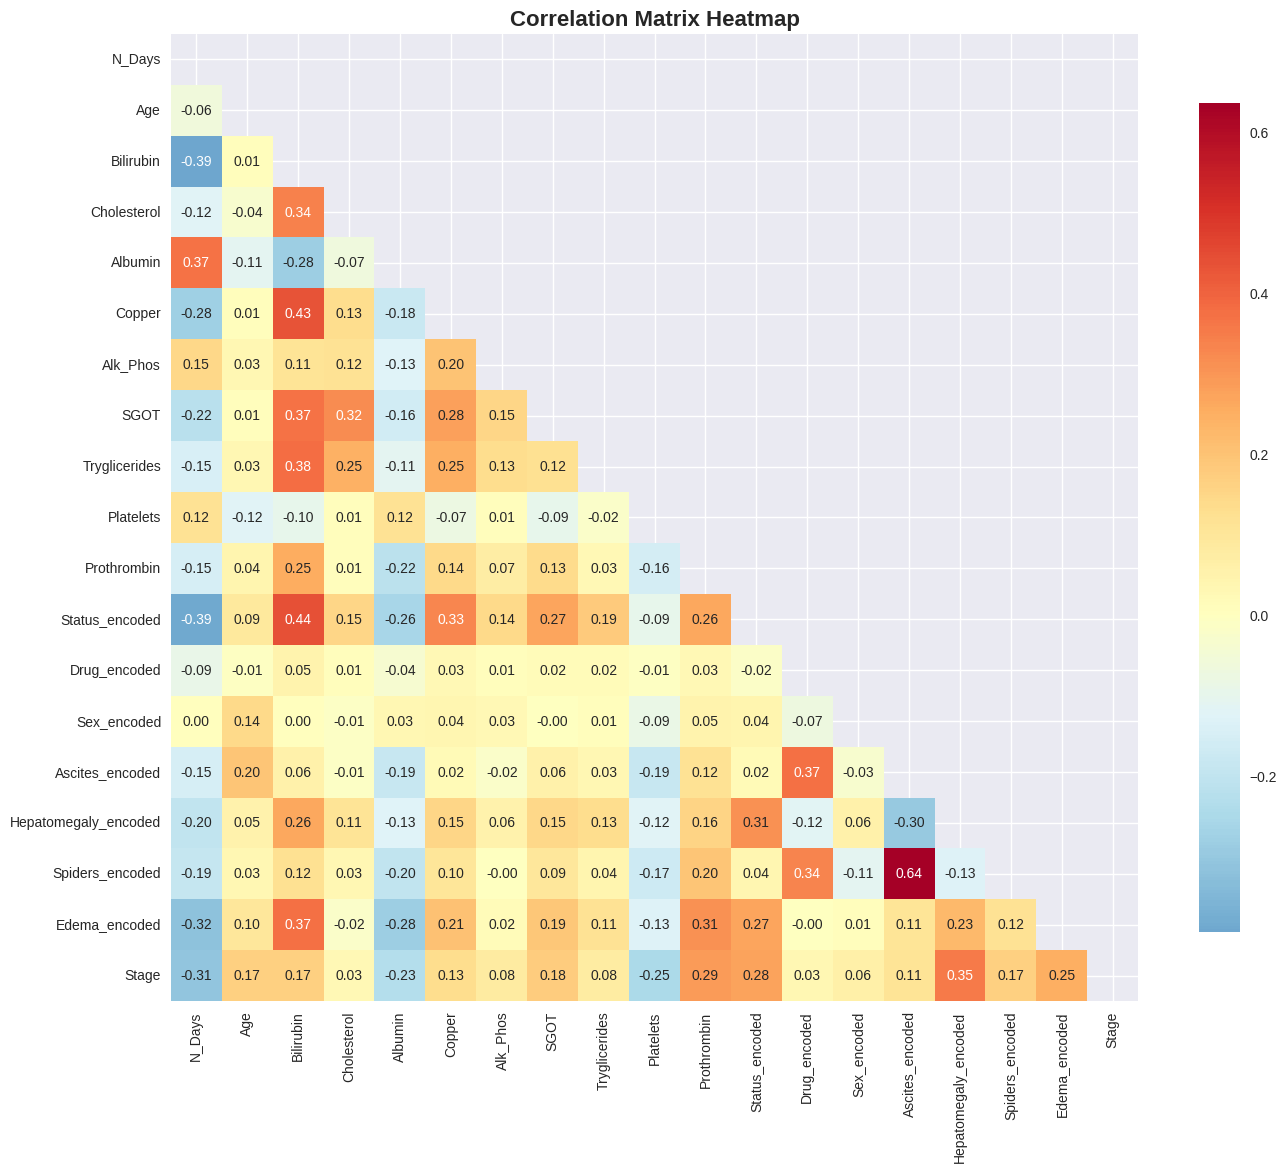

Features most correlated with Stage:
Hepatomegaly_encoded    0.353210
N_Days                  0.309484
Prothrombin             0.288107
Status_encoded          0.275194
Edema_encoded           0.251095
Platelets               0.250058
Albumin                 0.231631
SGOT                    0.175301
Spiders_encoded         0.168049
Bilirubin               0.168006
Name: Stage, dtype: float64


In [13]:
# 6. CORRELATION ANALYSIS
print("\n\n6. CORRELATION ANALYSIS")
print("-" * 25)

# Create a copy for correlation analysis
df_corr = df.copy()

# Encode categorical variables for correlation
le = LabelEncoder()
for col in categorical_cols:
    df_corr[col + '_encoded'] = le.fit_transform(df_corr[col].astype(str))

# Calculate correlation matrix
corr_cols = numerical_cols + [col + '_encoded' for col in categorical_cols] + ['Stage']
correlation_matrix = df_corr[corr_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Features most correlated with Stage
stage_correlations = correlation_matrix['Stage'].abs().sort_values(ascending=False)
print("Features most correlated with Stage:")
print(stage_correlations[1:11])  # Top 10 excluding Stage itself




7. FEATURE RELATIONSHIPS WITH STAGE
----------------------------------------


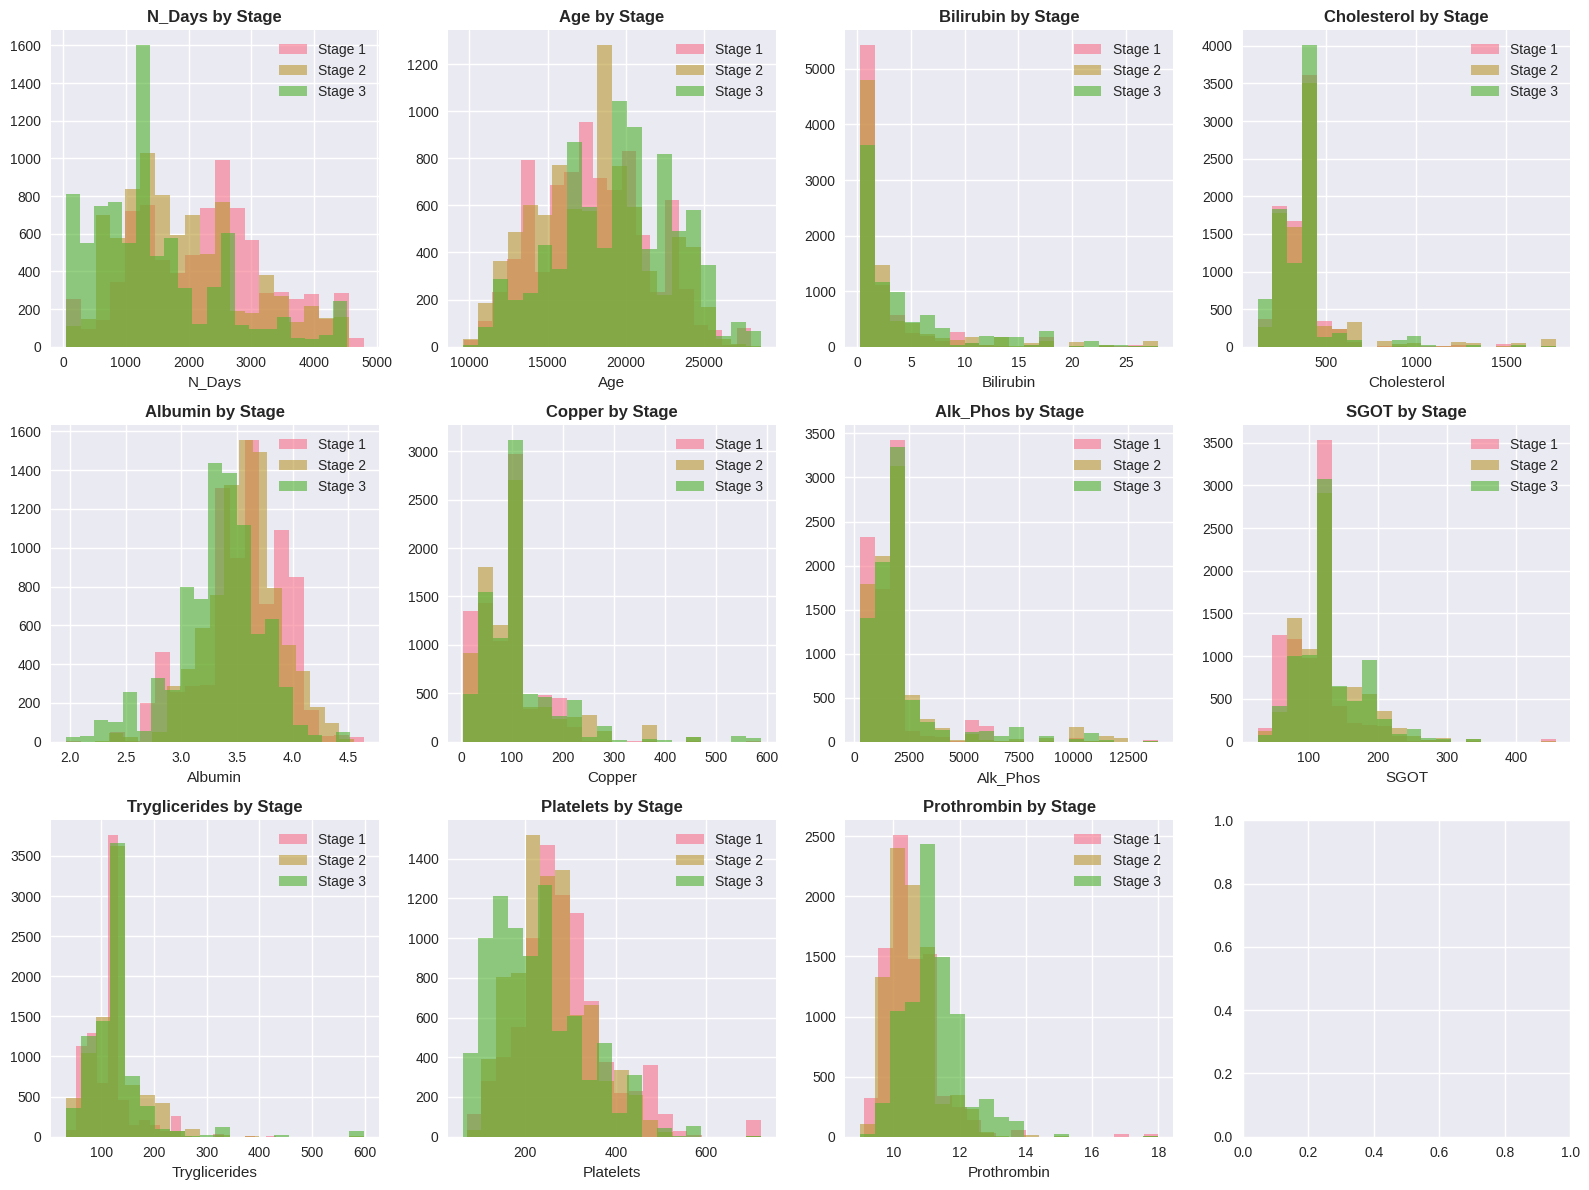

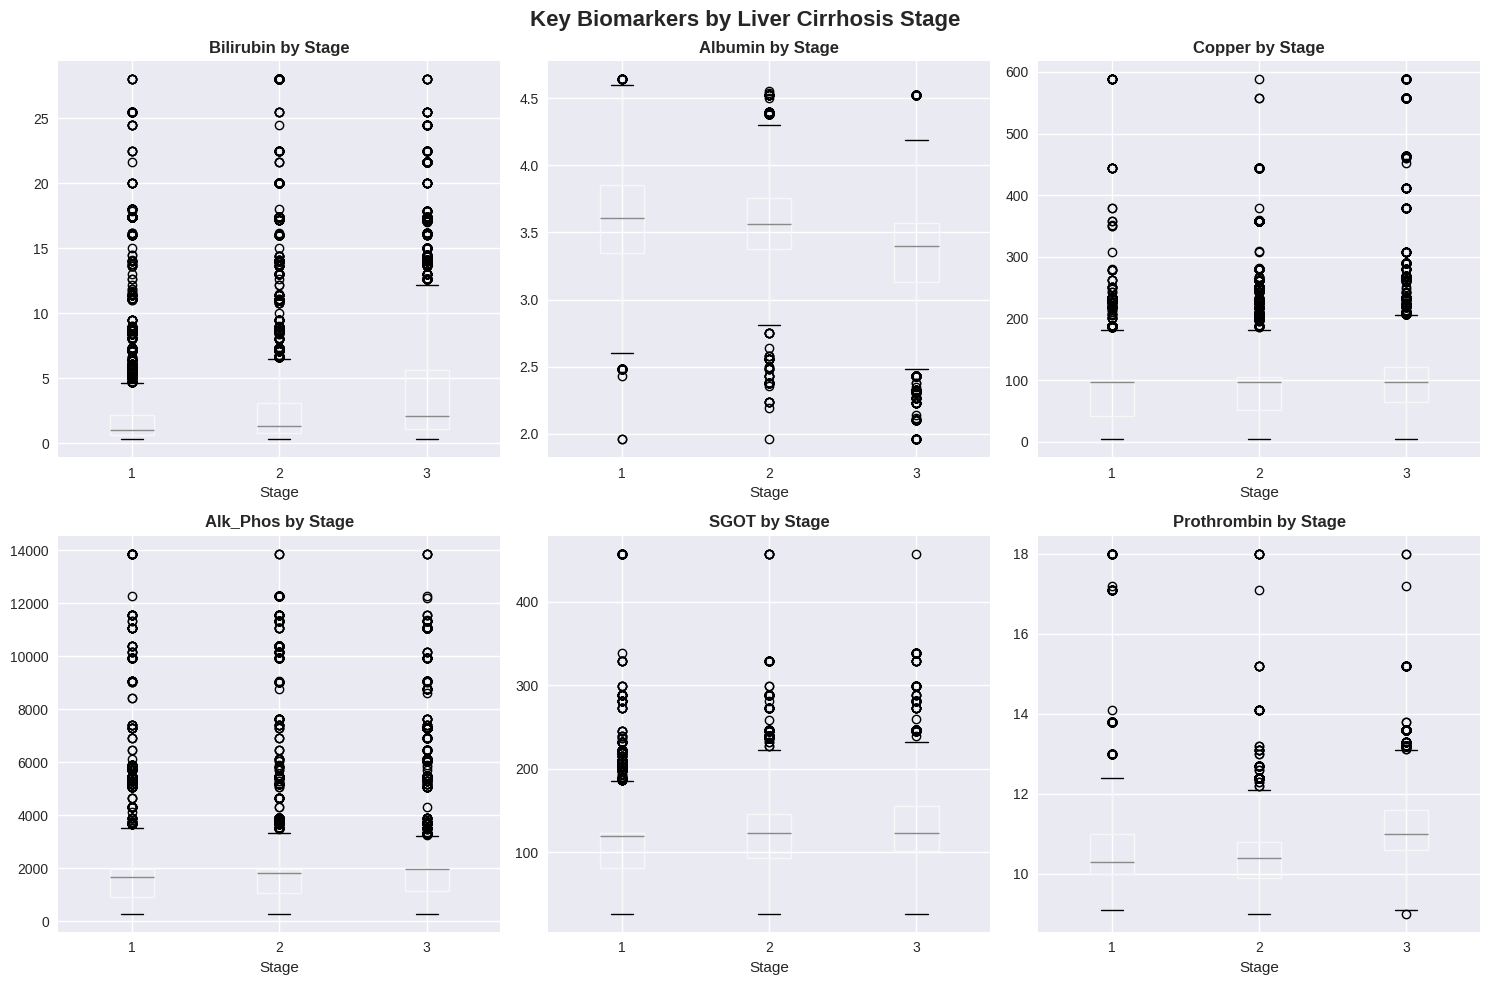


Statistical significance tests (ANOVA) for numerical features vs Stage:
----------------------------------------------------------------------
Bilirubin       | F-statistic:  365.293 | p-value: 0.000000 | Significant
Albumin         | F-statistic: 1028.297 | p-value: 0.000000 | Significant
Copper          | F-statistic:  222.406 | p-value: 0.000000 | Significant
Alk_Phos        | F-statistic:   95.800 | p-value: 0.000000 | Significant
SGOT            | F-statistic:  446.871 | p-value: 0.000000 | Significant
Prothrombin     | F-statistic: 1674.646 | p-value: 0.000000 | Significant


In [14]:
# 7. FEATURE RELATIONSHIPS WITH TARGET (STAGE)
print("\n\n7. FEATURE RELATIONSHIPS WITH STAGE")
print("-" * 40)

# Numerical features vs Stage
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols):
    for stage in sorted(df['Stage'].unique()):
        stage_data = df[df['Stage'] == stage][col].dropna()
        axes[i].hist(stage_data, alpha=0.6, label=f'Stage {stage}', bins=20)
    axes[i].set_title(f'{col} by Stage', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Box plots: Numerical features by Stage
key_numerical = ['Bilirubin', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Prothrombin']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(key_numerical):
    df.boxplot(column=col, by='Stage', ax=axes[i])
    axes[i].set_title(f'{col} by Stage', fontweight='bold')
    axes[i].set_xlabel('Stage')

plt.suptitle('Key Biomarkers by Liver Cirrhosis Stage', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistical tests for numerical features
print("\nStatistical significance tests (ANOVA) for numerical features vs Stage:")
print("-" * 70)

for col in key_numerical:
    # Group data by stage
    groups = [df[df['Stage'] == stage][col].dropna() for stage in sorted(df['Stage'].unique())]

    # Perform ANOVA
    f_stat, p_value = stats.f_oneway(*groups)

    print(f"{col:15} | F-statistic: {f_stat:8.3f} | p-value: {p_value:8.6f} | {'Significant' if p_value < 0.05 else 'Not Significant'}")




8. CATEGORICAL FEATURES VS STAGE
-----------------------------------

Status vs Stage Cross-tabulation:
Stage      1     2     3    All
Status                         
C       5676  4775  3065  13516
CL       723   616   689   2028
D       1866  3050  4540   9456
All     8265  8441  8294  25000
Chi-square statistic: 1938.356, p-value: 0.000000
Association: Significant

Drug vs Stage Cross-tabulation:
Stage               1     2     3    All
Drug                                    
D-penicillamine  3362  2741  3070   9173
Placebo          4903  5700  5224  15827
All              8265  8441  8294  25000
Chi-square statistic: 121.589, p-value: 0.000000
Association: Significant

Sex vs Stage Cross-tabulation:
Stage     1     2     3    All
Sex                           
F      7550  7411  7176  22137
M       715  1030  1118   2863
All    8265  8441  8294  25000
Chi-square statistic: 102.261, p-value: 0.000000
Association: Significant

Ascites vs Stage Cross-tabulation:
Stage       1     

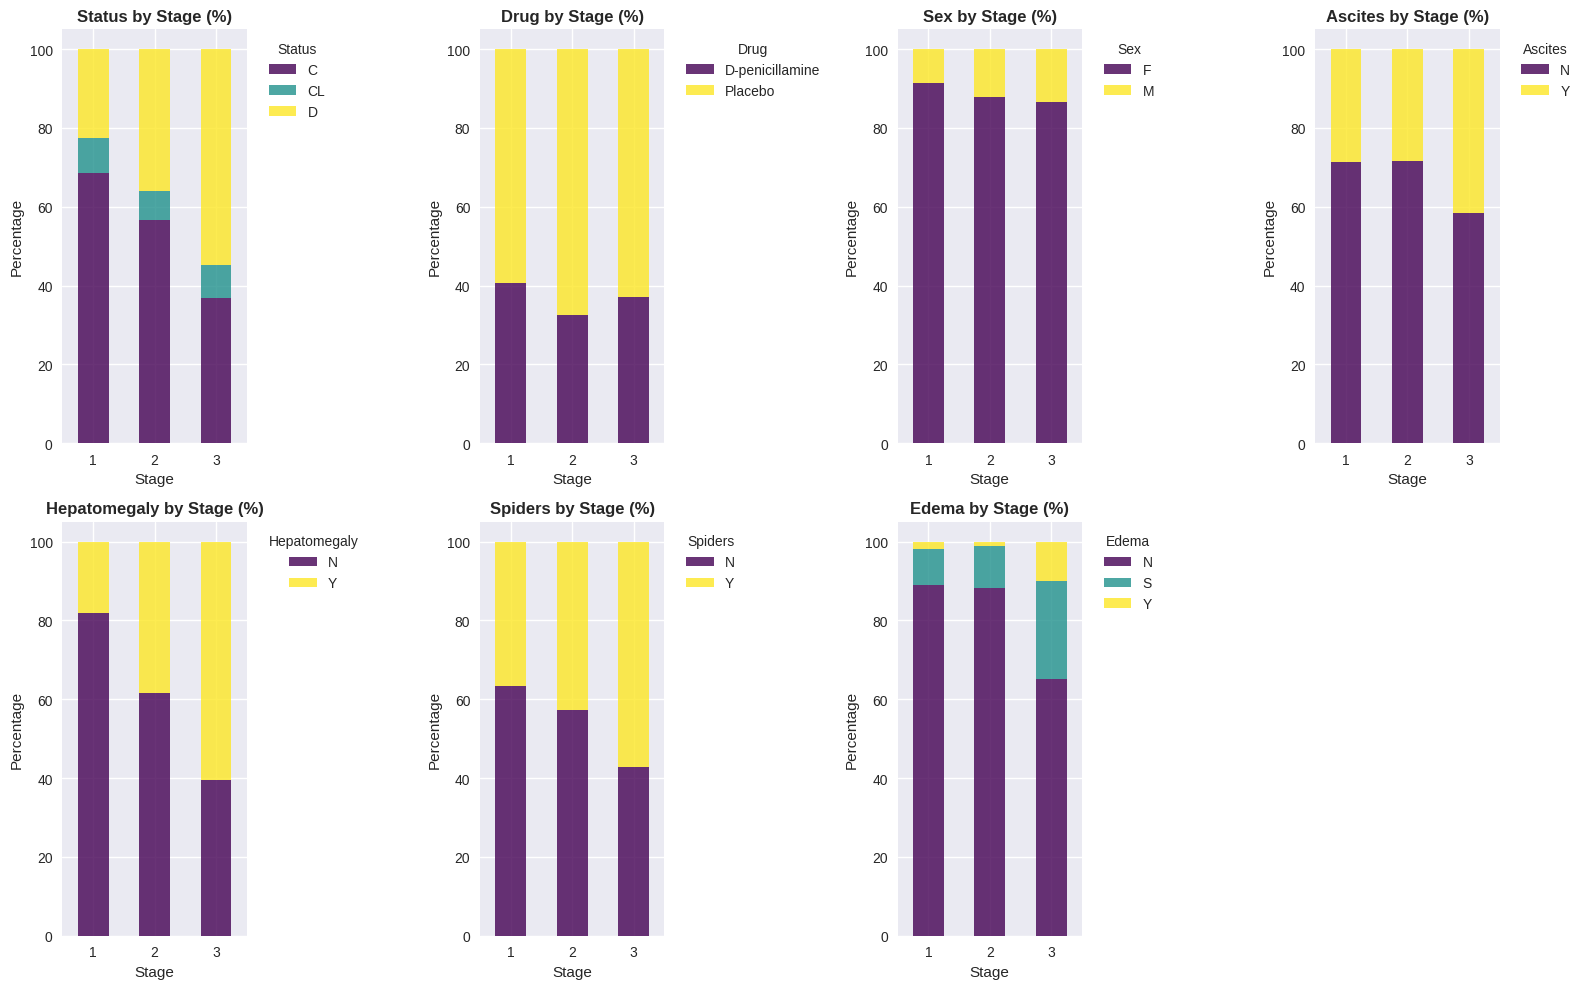

In [15]:
# 8. CATEGORICAL FEATURES VS STAGE
print("\n\n8. CATEGORICAL FEATURES VS STAGE")
print("-" * 35)

# Crosstabs and chi-square tests
for col in categorical_cols:
    print(f"\n{col} vs Stage Cross-tabulation:")
    crosstab = pd.crosstab(df[col], df['Stage'], margins=True)
    print(crosstab)

    # Chi-square test
    chi2, p_val, dof, expected = stats.chi2_contingency(crosstab.iloc[:-1, :-1])
    print(f"Chi-square statistic: {chi2:.3f}, p-value: {p_val:.6f}")
    print(f"Association: {'Significant' if p_val < 0.05 else 'Not Significant'}")

# Visualize categorical features by stage
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        # Stacked bar plot
        crosstab_norm = pd.crosstab(df['Stage'], df[col], normalize='index') * 100
        crosstab_norm.plot(kind='bar', stacked=True, ax=axes[i],
                          colormap='viridis', alpha=0.8)
        axes[i].set_title(f'{col} by Stage (%)', fontweight='bold')
        axes[i].set_xlabel('Stage')
        axes[i].set_ylabel('Percentage')
        axes[i].legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[i].tick_params(axis='x', rotation=0)

# Remove empty subplot
if len(categorical_cols) < len(axes):
    fig.delaxes(axes[len(categorical_cols)])

plt.tight_layout()
plt.show()



9. SURVIVAL AND STATUS ANALYSIS
-----------------------------------
Status distribution by Stage (%):
Status      C    CL      D
Stage                     
1       68.68  8.75  22.58
2       56.57  7.30  36.13
3       36.95  8.31  54.74

Survival time statistics by Stage:
       count     mean  median      std
Stage                                 
1       8265  2284.83  2286.0  1070.34
2       8441  1922.65  1725.0  1004.55
3       8294  1454.63  1301.0  1038.26


<Figure size 1200x600 with 0 Axes>

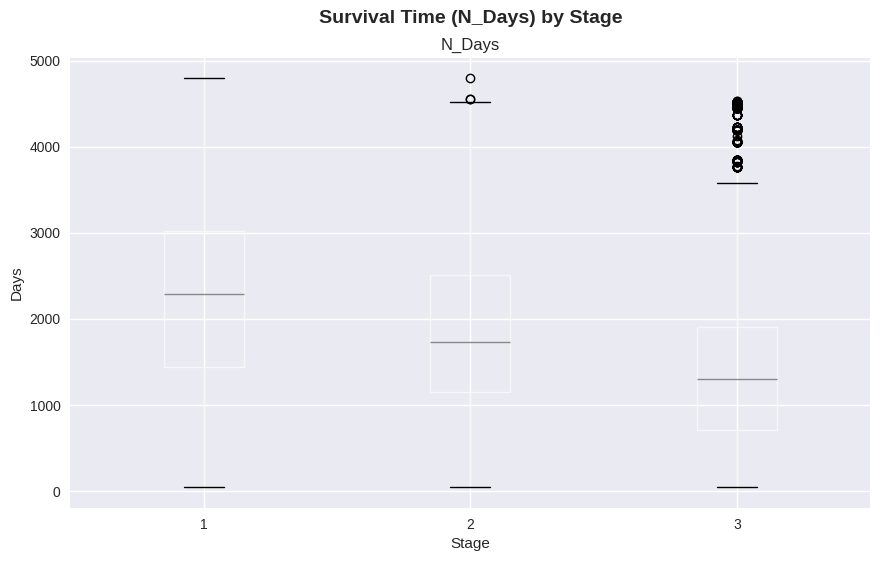

In [16]:
# 9. SURVIVAL ANALYSIS INSIGHTS
print("\n\n9. SURVIVAL AND STATUS ANALYSIS")
print("-" * 35)

# Status distribution by stage
status_stage = pd.crosstab(df['Stage'], df['Status'], normalize='index') * 100
print("Status distribution by Stage (%):")
print(status_stage.round(2))

# N_Days (survival time) by stage and status
print("\nSurvival time statistics by Stage:")
survival_stats = df.groupby('Stage')['N_Days'].agg(['count', 'mean', 'median', 'std']).round(2)
print(survival_stats)

# Visualize survival time by stage
plt.figure(figsize=(12, 6))
df.boxplot(column='N_Days', by='Stage', figsize=(10, 6))
plt.suptitle('Survival Time (N_Days) by Stage', fontsize=14, fontweight='bold')
plt.xlabel('Stage')
plt.ylabel('Days')
plt.show()

In [17]:
# 10. KEY INSIGHTS AND RECOMMENDATIONS
print("\n\n10. KEY INSIGHTS AND RECOMMENDATIONS")
print("-" * 42)

print("KEY FINDINGS:")
print("1. Dataset contains", len(df), "patients with liver cirrhosis stages 1-3")
print("2. Stage distribution:", dict(stage_counts))

# Identify most predictive features
top_predictors = stage_correlations[1:6].index.tolist()
print("3. Most predictive features for staging:")
for i, feature in enumerate(top_predictors, 1):
    clean_name = feature.replace('_encoded', '')
    print(f"   {i}. {clean_name} (correlation: {stage_correlations[feature]:.3f})")

print("\n4. Clinical significance:")
print("   - Higher stages associated with elevated Bilirubin, Copper, and Prothrombin time")
print("   - Lower Albumin levels in advanced stages")
print("   - Presence of ascites, edema strongly associated with disease progression")

print("\n5. Recommendations for modeling:")
print("   - Focus on biochemical markers: Bilirubin, Albumin, Copper, Prothrombin time")
print("   - Include clinical signs: Ascites, Edema, Hepatomegaly")
print("   - Consider feature engineering for enzyme ratios")
print("   - Handle class imbalance if present")
print("   - Validate model performance across all stages")

print("\n" + "="*60)
print("EDA ANALYSIS COMPLETED")
print("="*60)



10. KEY INSIGHTS AND RECOMMENDATIONS
------------------------------------------
KEY FINDINGS:
1. Dataset contains 25000 patients with liver cirrhosis stages 1-3
2. Stage distribution: {1: np.int64(8265), 2: np.int64(8441), 3: np.int64(8294)}
3. Most predictive features for staging:
   1. Hepatomegaly (correlation: 0.353)
   2. N_Days (correlation: 0.309)
   3. Prothrombin (correlation: 0.288)
   4. Status (correlation: 0.275)
   5. Edema (correlation: 0.251)

4. Clinical significance:
   - Higher stages associated with elevated Bilirubin, Copper, and Prothrombin time
   - Lower Albumin levels in advanced stages
   - Presence of ascites, edema strongly associated with disease progression

5. Recommendations for modeling:
   - Focus on biochemical markers: Bilirubin, Albumin, Copper, Prothrombin time
   - Include clinical signs: Ascites, Edema, Hepatomegaly
   - Consider feature engineering for enzyme ratios
   - Handle class imbalance if present
   - Validate model performance across 